In [4]:


from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    # exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    load_signal=True, 
    desc_add="clean-with-fd-clamped",
    ignore_boundary_trs=0,
    load_eog=False,
)



Skipping subject 01 with too few runs 3
Skipping subject 07 with too few runs 2
Skipping subject 11 with too few runs 2
Skipping subject 12 with too few runs 3
Skipping subject 13 with too few runs 2
Skipping subject 31 with too few runs 3


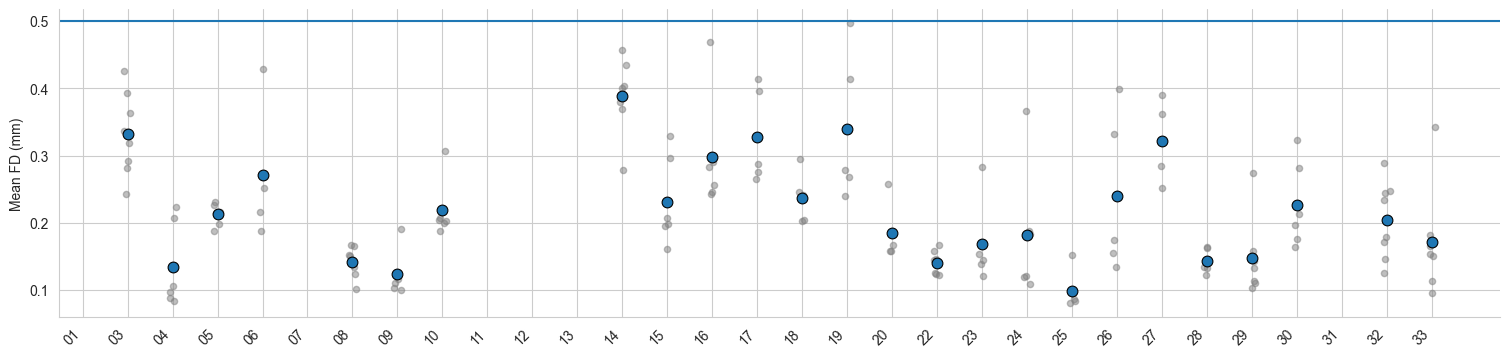

In [8]:

from matplotlib import pyplot as plt
import numpy as np 
subject_fd_means = {}
for subject, run, run_df in mrio.iter_run_events(run_exclusion=True): 
    df = mrio.load_confounds(subject=subject, run=run, confound_names=["framewise_displacement"])
    subject_fd_means.setdefault(subject, []).append(df["framewise_displacement"].mean())
    
data = subject_fd_means
jitter=0.08
fig, ax = plt.subplots(figsize=(max(4, 0.6 * len(data)), 4))

subjects = list(data.keys())

for i, subj in enumerate(subjects):
    vals = np.asarray(data[subj], dtype=float)
    if len(vals) < 4:
        print(f"Skipping subject {subj} with too few runs {len(vals)}")
        continue
    x = i + np.random.uniform(-jitter, jitter, size=vals.size)
    ax.scatter(x, vals, alpha=0.5, color='gray', s=20, zorder=1)
    ax.scatter(i, vals.mean(), color='C0', s=60, zorder=2,
               edgecolor='black', linewidth=0.8)

ax.axhline(0.5)
ax.set_xticks(range(len(subjects)))
ax.set_xticklabels(subjects, rotation=45, ha='right')
ax.set_ylabel('Mean FD (mm)')
ax.spines[['top', 'right']].set_visible(False)

In [3]:
for subj in mrio.subjects:
    run_count = len(mrio.events[mrio.events["subject"] == subj]["run"].unique())
    if run_count < 4:
        print(f"subj-{subj} only has {run_count} runs")

subj-01 only has 3 runs
subj-12 only has 3 runs


In [4]:
|import numpy as np

def create_blocks(arr, trim: int):
    # Get indices where values are not NaN
    valid = ~np.isnan(arr)
    # Find contiguous blocks
    changes = np.diff(valid.astype(int))
    block_starts = np.where(changes == 1)[0] + 1
    block_ends = np.where(changes == -1)[0] + 1
    
    # Handle edge cases where array starts/ends with valid values
    if valid[0]:
        block_starts = np.concatenate([[0], block_starts])
    if valid[-1]:
        block_ends = np.concatenate([block_ends, [len(arr)]])
    
    blocks = [arr[s+trim:e-trim] for s, e in zip(block_starts, block_ends) 
          if (e - trim) - (s + trim) > 0]
    return blocks


def permute_labels(blocks):
    labels = [l for _, l in blocks]
    np.random.shuffle(labels)
    return [(b, l) for (b, _), l in zip(blocks, labels)]


In [5]:
from scipy.stats import zscore

l1 = "W"
l2 = "S"

subject_blocks = {}
for subject in mrio.subjects:
    blocks = []
    
    # For each run, get contiguous sleep and wake blocks,
    # trimming the edge TRs off
    for _, run, run_df in mrio.iter_run_events(subject=subject):
        eye_signal = run_df["mreyemove"]
        wake = np.full_like(eye_signal, np.nan)
        wake[run_df[l1]] = eye_signal[run_df[l1]]
        for block in create_blocks(wake, trim=7):
            blocks.append((block, l1))
        
        sleep = np.full_like(eye_signal, np.nan)
        sleep[run_df[l2]] = eye_signal[run_df[l2]]
        for block in create_blocks(sleep, trim=1):
            blocks.append((block, l2))
    
    subject_blocks[subject] = blocks
        
subject_blocks = {
    s: blocks for s, blocks in subject_blocks.items()
    if any(l == l2 for _, l in blocks)  
}
    

In [33]:
import numpy as np
from scipy.signal import welch
from collections import defaultdict

def psd_by_state(blocks_by_subject, fs, nperseg=16):
    """
    nperseg should be ≤ shortest block you want to keep.
    Blocks shorter than nperseg are dropped (and counted).
    """
    subject_psds = defaultdict(lambda: defaultdict(list))
    f_ref = None
    kept, dropped = defaultdict(int), defaultdict(int)

    for subj, blocks in blocks_by_subject.items():
        for arr, state in blocks:
            arr = np.asarray(arr, dtype=float)
            if len(arr) < nperseg:
                dropped[state] += 1
                continue
            f, p = welch(arr, fs=fs, nperseg=nperseg,
                         detrend='linear', average='median')
            if f_ref is None:
                f_ref = f
            subject_psds[state][subj].append((p, len(arr)))
            kept[state] += 1

    print(f"Kept per state: {dict(kept)}")
    print(f"Dropped (too short): {dict(dropped)}")

    mean, sem, n_subj = {}, {}, {}
    for state, by_subj in subject_psds.items():
        per_subj = []
        for items in by_subj.values():
            psds = np.array([p for p, _ in items])
            ws = np.array([w for _, w in items])
            per_subj.append(np.average(psds, axis=0, weights=ws))
        per_subj = np.array(per_subj)
        mean[state] = per_subj.mean(0)
        sem[state] = per_subj.std(0, ddof=1) / np.sqrt(len(per_subj))
        n_subj[state] = len(per_subj)

    return f_ref, mean, sem, n_subj

psds = psd_by_state(subject_blocks, 1/2.1, nperseg=16)

Kept per state: {'W': 166, 'S': 248}
Dropped (too short): {'W': 92, 'S': 94}


In [47]:
psds[2]

{'W': array([2.05855472e-05, 8.45297153e-05, 6.92290841e-05, 4.18602003e-05,
        2.61014975e-05, 1.59860880e-05, 8.97652564e-06, 3.90039796e-06,
        8.99690714e-07]),
 'S': array([1.96489484e-05, 2.63735980e-04, 3.31627618e-04, 1.89178732e-04,
        1.17191772e-04, 9.18776730e-05, 3.80400536e-05, 1.33803255e-05,
        3.34281825e-06])}

In [45]:
from collections import defaultdict
import numpy as np

kept_lens = defaultdict(list)
for blocks in subject_blocks.values():
    for arr, state in blocks:
        if len(arr) >= 16:
            kept_lens[state].append(len(arr))

for state, ls in kept_lens.items():
    print(f"{state}: n={len(ls)}, "
          f"median={np.median(ls):.0f}, "
          f"p25={np.percentile(ls,25):.0f}, "
          f"p75={np.percentile(ls,75):.0f}, "
          f"max={max(ls)}")

W: n=166, median=100, p25=43, p75=307, max=413
S: n=248, median=69, p25=40, p75=198, max=425


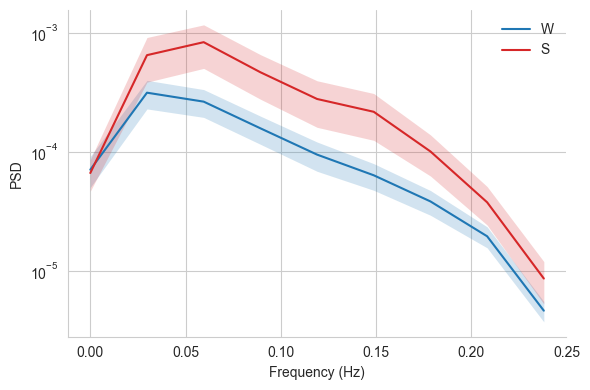

In [48]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
colors = {'W': 'C0', 'S': 'C3'}
mean = psds[1]
sem = psds[2]
freqs = psds[0]
for state in ['W', 'S']:
    m = mean[state]
    s = sem[state]   # or whatever you have — sd, sem, ci half-width

    ax.plot(freqs, m, color=colors[state], label=state)
    ax.fill_between(freqs, m - s, m + s,
                    color=colors[state], alpha=0.2, linewidth=0)

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD')
ax.set_yscale('log')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

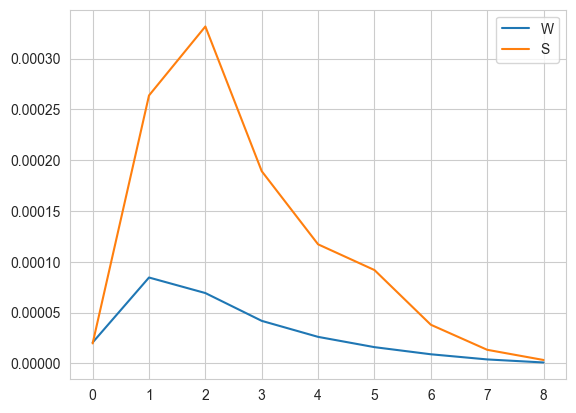

In [43]:
plt.plot(psds[2]["W"], label="W")
apltx.fill_between(psds[0], m - s, m + s,
                color=colors[state], alpha=0.2, linewidth=0)
plt.plot(psds[2]["S"], label="S")


    ax.plot(freqs, m, color=colors[state], label=state)
plt.legend()

In [25]:
from collections import defaultdict

lens = defaultdict(list)
for blocks in subject_blocks.values():
    for arr, state in blocks:
        lens[state].append(len(arr))
        
sum(np.array(lens["S"]) > 10 ) / len(lens["S"])

1.0

In [22]:
lens["S"]

[12,
 41,
 154,
 340,
 255,
 98,
 227,
 140,
 12,
 13,
 254,
 55,
 12,
 12,
 26,
 27,
 12,
 98,
 183,
 26,
 354,
 411,
 27,
 55,
 54,
 155,
 27,
 41,
 425,
 41,
 41,
 126,
 369,
 12,
 12,
 283,
 41,
 68,
 12,
 27,
 13,
 41,
 12,
 140,
 69,
 168,
 27,
 27,
 197,
 26,
 241,
 13,
 269,
 70,
 12,
 11,
 26,
 69,
 27,
 13,
 55,
 12,
 55,
 12,
 40,
 12,
 12,
 26,
 26,
 11,
 12,
 12,
 26,
 26,
 12,
 70,
 26,
 27,
 41,
 56,
 26,
 12,
 27,
 27,
 127,
 40,
 69,
 12,
 98,
 13,
 69,
 68,
 26,
 140,
 198,
 26,
 55,
 13,
 26,
 98,
 68,
 55,
 13,
 84,
 55,
 83,
 12,
 12,
 12,
 12,
 26,
 27,
 13,
 12,
 112,
 27,
 13,
 140,
 255,
 41,
 68,
 27,
 27,
 69,
 26,
 13,
 27,
 12,
 12,
 12,
 26,
 11,
 27,
 211,
 41,
 26,
 12,
 13,
 84,
 12,
 12,
 41,
 26,
 126,
 12,
 27,
 55,
 425,
 26,
 83,
 268,
 97,
 112,
 168,
 40,
 368,
 425,
 12,
 69,
 26,
 425,
 425,
 425,
 425,
 425,
 411,
 383,
 425,
 97,
 311,
 127,
 27,
 12,
 12,
 12,
 12,
 27,
 254,
 26,
 69,
 55,
 40,
 126,
 12,
 40,
 26,
 26,
 113,
 98,
 83,
 283

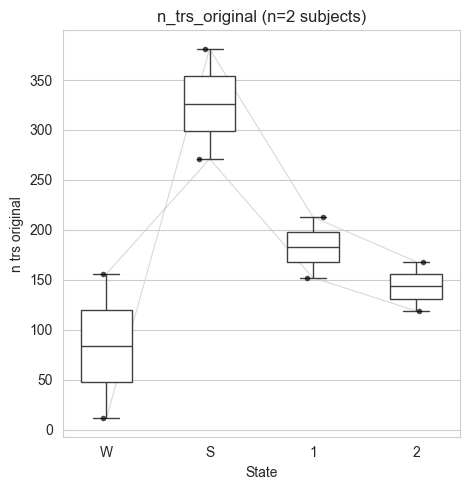

In [53]:
import pandas as pd 
import numpy as np 

def compute_erosion_loss(
    df: pd.DataFrame,
    state_cols: list[str],
    n_trs: int,
    subject_col: str = "subject",
    run_col: str = "run",
) -> pd.DataFrame:
    """
    Compute TRs lost to mask erosion, per run and per state.

    Parameters
    ----------
    df : pd.DataFrame
        Long-format events dataframe with one row per TR, containing
        subject_col, run_col, and the state mask columns.
    state_cols : list[str]
        Names of boolean state mask columns.
    n_trs : int
        Number of TRs eroded on each side of every transition.
    subject_col, run_col : str
        Column names for grouping.

    Returns
    -------
    pd.DataFrame
        One row per (subject, run, state) with columns:
        - n_trs_total: total TRs in the run
        - n_trs_original: TRs where original mask is True
        - n_trs_eroded: TRs where eroded mask is True
        - n_trs_lost: TRs lost to erosion
        - pct_lost_of_run: lost TRs as % of run length
        - pct_lost_of_state: lost TRs as % of original state coverage
        - n_transitions: number of state changes in the run
    """
    rows = []
    for (subj, run), group in df.groupby([subject_col, run_col], sort=False):
        n_total = len(group)
        for state in state_cols:
            mask = group[state].astype(bool).to_numpy()
            eroded = mrio._erode_mask_at_transitions(mask, n_trs)
            n_orig = int(mask.sum())
            n_erod = int(eroded.sum())
            n_lost = n_orig - n_erod
            n_trans = int((np.diff(mask.astype(np.int8)) != 0).sum())
            rows.append({
                subject_col: subj,
                run_col: run,
                "state": state,
                "n_trs_total": n_total,
                "n_trs_original": n_orig,
                "n_trs_eroded": n_erod,
                "n_trs_lost": n_lost,
                "pct_lost_of_run": 100 * n_lost / n_total if n_total else np.nan,
                "pct_lost_of_state": 100 * n_lost / n_orig if n_orig else np.nan,
                "n_transitions": n_trans,
            })
    return pd.DataFrame(rows)

import matplotlib.pyplot as plt
import seaborn as sns

def plot_erosion_loss(
    loss_df: pd.DataFrame,
    state_cols: list[str] = ("W", "S"),
    metric: str = "n_trs_lost",
    plot_type: str = "box",
    subject_col: str = "subject",
):
    """
    Plot TRs lost to mask erosion, one panel per state.

    Parameters
    ----------
    loss_df : pd.DataFrame
        Output of compute_erosion_loss.
    state_cols : sequence of str
        Which states to plot (one panel each).
    metric : str
        Column to plot. Common choices: "n_trs_lost", "pct_lost_of_run",
        "pct_lost_of_state".
    plot_type : str
        "box" (one box per subject's runs), "strip" (raw points per run),
        or "bar" (per-subject mean with error bar).
    """
    fig, axes = plt.subplots(1, len(state_cols), figsize=(6 * len(state_cols), 5),
                              sharey=True)
    if len(state_cols) == 1:
        axes = [axes]
        
    order = (loss_df.groupby(subject_col)[metric]
                       .mean()
                       .sort_values(ascending=False)
                       .index.tolist())

    for ax, state in zip(axes, state_cols):
        sub = loss_df[loss_df["state"] == state]

        # # Order subjects by mean of the metric, descending
        # order = (sub.groupby(subject_col)[metric]
        #             .mean()
        #             .sort_values(ascending=False)
        #             .index.tolist())


        if plot_type == "box":
            sns.boxplot(data=sub, x=subject_col, y=metric, ax=ax,  order=order,color="lightgray")
            sns.stripplot(data=sub, x=subject_col, y=metric, ax=ax, order=order,
                          color="black", size=3, alpha=0.6)
        elif plot_type == "strip":
            sns.stripplot(data=sub, x=subject_col, y=metric, ax=ax, order=order,
                          size=4, alpha=0.7)
        elif plot_type == "bar":
            per_subj = sub.groupby(subject_col)[metric].agg(["mean", "std"]).reset_index()
            ax.bar(per_subj[subject_col].astype(str), per_subj["mean"], order=order,
                   yerr=per_subj["std"], color="steelblue", alpha=0.8)
        else:
            raise ValueError(f"Unknown plot_type: {plot_type}")

        ax.set_title(f"{state.capitalize()}")
        ax.set_xlabel("Subject")
        ax.set_ylabel(metric.replace("_", " "))
        ax.tick_params(axis="x", rotation=90)

    fig.suptitle(f"TRs lost to mask erosion — {metric}", fontsize=12)
    fig.tight_layout()
    return fig, axes


import matplotlib.pyplot as plt
import seaborn as sns

def plot_subj_erosion_loss(
    loss_df: pd.DataFrame,
    state_cols: list[str] = ("W", "S"),
    metric: str = "n_trs_lost",
    plot_type: str = "box",
    subject_col: str = "subject",
    order_by: str | None = None,
    ascending: bool = False,
):
    """
    Plot TRs lost to mask erosion, with states as grouped bars/boxes per subject.

    Parameters
    ----------
    loss_df : pd.DataFrame
        Output of compute_erosion_loss.
    state_cols : sequence of str
        Which states to plot (one color each).
    metric : str
        Column to plot. Common choices: "n_trs_lost", "pct_lost_of_run",
        "pct_lost_of_state".
    plot_type : str
        "box" (boxes per state per subject), "strip" (raw points per run),
        or "bar" (per-subject mean with error bar).
    order_by : str | None
        If None, order by mean metric across all states. If a state name
        (e.g., "W"), order by mean metric within that state.
    ascending : bool
        Sort order. Default False = descending.
    """
    # Filter to requested states
    plot_df = loss_df[loss_df["state"].isin(state_cols)].copy()

    # Compute subject ordering
    if order_by is None:
        ordering_data = plot_df
    else:
        ordering_data = plot_df[plot_df["state"] == order_by]

    order = (ordering_data.groupby(subject_col)[metric]
                          .mean()
                          .sort_values(ascending=ascending)
                          .index.tolist())

    fig, ax = plt.subplots(figsize=(max(8, 0.4 * len(order)), 5))

    if plot_type == "box":
        sns.boxplot(data=plot_df, x=subject_col, y=metric, hue="state",
                    order=order, hue_order=list(state_cols), ax=ax)
    elif plot_type == "strip":
        sns.stripplot(data=plot_df, x=subject_col, y=metric, hue="state",
                      order=order, hue_order=list(state_cols),
                      dodge=True, size=4, alpha=0.7, ax=ax)
    elif plot_type == "bar":
        sns.barplot(data=plot_df, x=subject_col, y=metric, hue="state",
                    order=order, hue_order=list(state_cols),
                    errorbar="sd", ax=ax)
    else:
        raise ValueError(f"Unknown plot_type: {plot_type}")

    ax.set_xlabel("Subject")
    ax.set_ylabel(metric.replace("_", " "))
    ax.set_title(f"TRs lost to mask erosion — {metric}")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(title="State", loc="best")
    fig.tight_layout()
    return fig, ax

def plot_group_erosion_loss(
    loss_df: pd.DataFrame,
    state_cols: list[str] = ("W", "S"),
    metric: str = "n_trs_lost",
    plot_type: str = "box",
    subject_col: str = "subject",
    agg: str = "mean",
    show_subject_lines: bool = False,
):
    """
    Plot TRs lost to mask erosion at the group level: states on x-axis,
    one dot per subject (aggregated within subject first).

    Parameters
    ----------
    loss_df : pd.DataFrame
        Output of compute_erosion_loss.
    state_cols : sequence of str
        Which states to plot.
    metric : str
        Column to plot.
    plot_type : str
        "box", "bar", or "violin" — overlaid with subject-level points.
    subject_col : str
        Column identifying subjects.
    agg : str
        How to collapse multiple runs within a subject/state ("mean" or "median").
    show_subject_lines : bool
        If True, connect dots belonging to the same subject across states
        (useful for within-subject designs).
    """
    plot_df = loss_df[loss_df["state"].isin(state_cols)].copy()

    # Collapse to one value per subject per state
    subj_df = (plot_df.groupby([subject_col, "state"])[metric]
                      .agg(agg)
                      .reset_index())

    fig, ax = plt.subplots(figsize=(max(4, 1.2 * len(state_cols)), 5))

    if plot_type == "box":
        sns.boxplot(data=subj_df, x="state", y=metric, order=list(state_cols),
                    showfliers=False, width=0.5, ax=ax,
                    boxprops=dict(facecolor="white"))
    elif plot_type == "bar":
        sns.barplot(data=subj_df, x="state", y=metric, order=list(state_cols),
                    errorbar="se", ax=ax, alpha=0.6)
    elif plot_type == "violin":
        sns.violinplot(data=subj_df, x="state", y=metric, order=list(state_cols),
                       inner=None, ax=ax, color="lightgray")
    else:
        raise ValueError(f"Unknown plot_type: {plot_type}")

    # Subject-level points on top
    sns.stripplot(data=subj_df, x="state", y=metric, order=list(state_cols),
                  color="black", size=4, alpha=0.7, jitter=0.1, ax=ax)

    # Optional within-subject lines
    if show_subject_lines:
        wide = subj_df.pivot(index=subject_col, columns="state", values=metric)
        wide = wide.reindex(columns=list(state_cols))
        for _, row in wide.iterrows():
            ax.plot(range(len(state_cols)), row.values,
                    color="gray", alpha=0.3, lw=0.8, zorder=0)

    ax.set_xlabel("State")
    ax.set_ylabel(metric.replace("_", " "))
    ax.set_title(f"{metric} (n={subj_df[subject_col].nunique()} subjects)")
    fig.tight_layout()
    return fig, ax

df = mrio.events
state = ["W", "S", "1", "2"]
# state = ["W", "1", "2"]
loss_df = compute_erosion_loss(df, state_cols=state, n_trs=7)

# Box plot per subject (one box = one subject's distribution across runs)
# fig, axes = plot_subj_erosion_loss(loss_df, state_cols=["W", "S"],
#                                metric="n_trs_original", plot_type="box")

plot_group_erosion_loss(loss_df[loss_df["subject"].isin(["09", "07"])], state_cols=state,
                               metric="n_trs_original", plot_type="box", show_subject_lines=True,  agg="mean")
plt.show()


# # Per-run summary across all runs
# print(loss_df.groupby("state")[["n_trs_lost", "pct_lost_of_run", "pct_lost_of_state"]]
#             .agg(["mean", "median", "std", "min", "max"]))
# 
# # Per-subject average (averaging across that subject's runs first)
# per_subject = (loss_df
#                .groupby(["subject", "state"])
#                [["n_trs_lost", "pct_lost_of_run", "pct_lost_of_state", "n_transitions"]]
#                .mean()
#                .reset_index())
# 
# # Then group-level mean across subjects
# print(per_subject.groupby("state").agg(["mean", "std"]))

In [58]:
per_subject = (loss_df.groupby(["subject", "state"])["n_trs_original"]
                      .mean()                          # mean across runs per subject
                      .reset_index())

summary = per_subject.groupby("state")["n_trs_original"].agg(
    median="median",
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
)
print(summary)

           median         q25         q75
state                                    
1      128.000000   71.458333  194.075000
2       49.666667    6.583333  122.333333
S      230.000000  140.428571  290.416667
W      197.000000  104.333333  285.571429


In [45]:
plot_df = loss_df[loss_df["state"].isin(state)].copy()

# Collapse to one value per subject per state
summary = (plot_df.groupby("state")["n_trs_original"]
             .agg(median="median",
                  q25=lambda x: x.quantile(0.25),
                  q75=lambda x: x.quantile(0.75)))
print(summary)

# df.groupby('category')['value'].agg(['mean', 'std'])

       median   q25    q75
state                     
1       113.0  14.0  227.0
2         0.0   0.0  157.0
S       243.0  27.0  383.0
W       169.0  28.0  398.0


In [11]:
fully_lost = loss_df[loss_df["pct_lost_of_state"] == 100]
print(fully_lost.groupby("state").size())
print(fully_lost[["subject", "run", "state", "n_trs_original", "n_transitions"]])

state
S    20
W    32
dtype: int64
    subject  run state  n_trs_original  n_transitions
1        09    1     S              58              6
16       10    3     W              43              3
18       10    4     W              14              1
21       10    5     S              29              2
35       22    6     S              28              4
36       22    7     W              29              4
48       01    1     W              44              4
54       18    1     W              57              7
66       25    2     W              86             10
68       25    3     W              57              5
75       25    6     S              56              8
77       17    1     S              57              4
79       17    2     S              15              2
82       17    4     W              57              5
87       17    6     S              57              8
91       33    1     S              42              6
93       33    2     S              41         

In [15]:

l1 = "W"
l2 = "1"
l3 = "2"

subject_blocks_three_state = {}
for subject in mrio.subjects:
    blocks = []
    
    # For each run, get contiguous sleep and wake blocks,
    # trimming the edge TRs off
    for _, run, run_df in mrio.iter_run_events(subject=subject):
        eye_signal = run_df["mreyemove"]
        one = np.full_like(eye_signal, np.nan)
        one[run_df[l1]] = eye_signal[run_df[l1]]
        for block in create_blocks(one, trim=1):
            blocks.append((block, l1))
        
        two = np.full_like(eye_signal, np.nan)
        two[run_df[l2]] = eye_signal[run_df[l2]]
        for block in create_blocks(two, trim=1):
            blocks.append((block, l2))
            
        three = np.full_like(eye_signal, np.nan)
        three[run_df[l3]] = eye_signal[run_df[l3]]
        for block in create_blocks(three, trim=1):
            blocks.append((block, l3))
    
    subject_blocks_three_state[subject] = blocks
        
subject_blocks_three_state = {
    s: blocks for s, blocks in subject_blocks_three_state.items()
    if any(l == l1 for _, l in blocks) 
    and any(l == l2 for _, l in blocks) 
    and any(l == l3 for _, l in blocks)
}
print(f"Subjects with all three states: {len(subject_blocks_three_state)}/{len(mrio.subjects)}")

Subjects with all three states: 20/27


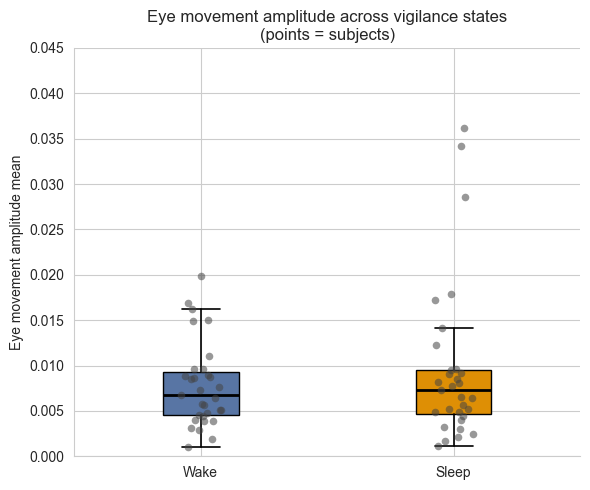

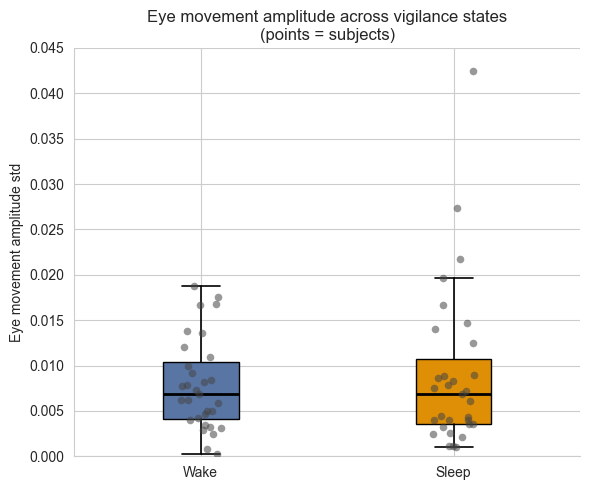

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

def get_state_values(subject_blocks, label, stat):
    subjects = list(subject_blocks.keys())
    result = []
    for s in subjects:
        blocks = [b for b, l in subject_blocks[s] if l == label]
        if len(blocks) > 0:
            result.append((s, stat(np.concatenate(blocks))))
        else:
            result.append((s, np.nan))
    return result  # list of (subject, value) tuples, nan if no data


states = {"W": "Wake", "S": "Sleep"}
colors = {"W": "#5875a4ff", "S": "#de8f05ff"}

for stat, desc in zip([np.mean, np.std], ["mean", "std"]):
    # Compute per-subject mean for each state
    state_values = {}
    for label in states:
        state_values[label] = {s: v for s, v in get_state_values(subject_blocks, label, stat)}
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Boxplots
    bp = ax.boxplot(
        [np.array([v for v in state_values[l].values() if not np.isnan(v)]) for l in states],
        positions=range(2),
        widths=0.3,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=4, alpha=0.5),
        zorder=2
    )
    
    for patch, label in zip(bp['boxes'], states):
        patch.set_facecolor(colors[label])
        patch.set_alpha(1)
    
    # Per-subject lines
    # subjects = list(subject_blocks_three_state.keys())
    # for subject in subjects:
    #     vals = [(j, state_values[l][subject]) for j, l in enumerate(states) 
    #             if not np.isnan(state_values[l][subject])]
    #     if len(vals) > 1:
    #         positions, values = zip(*vals)
    #         ax.plot(positions, values, color="gray", alpha=0.2, linewidth=0.8, zorder=1)
    
    # Jittered subject points
    for j, label in enumerate(states):
        valid = np.array([v for v in state_values[label].values() if not np.isnan(v)])
        jitter = np.random.uniform(-0.08, 0.08, len(valid))
        ax.scatter(
            np.full(len(valid), j) + jitter,
            valid,
            color="#4444448c", alpha=0.55, s=30, zorder=3,
            edgecolors='white', linewidths=0
        )
    
    ax.set_xticks(range(2))
    ax.set_xticklabels(states.values())
    ax.set_ylabel(f"Eye movement amplitude {desc}")
    ax.set_title("Eye movement amplitude across vigilance states\n(points = subjects)")
    ax.set_ylim(0,0.045)
    ax.spines[["top", "right"]].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    fig.savefig(f"/Users/zach/2025_RA/matthias/final images/eye_voxels/{desc}_amplitude_states.svg", dpi=300)


In [32]:
new_df = mrio.split_regressor(
            run_df=mrio.events,
            regressor_name="mreyemove",
            state_cols=["W", "S"],
            fill_value=np.nan,
        )
new_df["mreyemove_W"]

0        0.000000
1        0.000000
2        0.000000
3        0.000000
4        0.000000
           ...   
80698    0.004946
80699    0.006854
80700    0.007067
80701    0.002832
80702    0.002515
Name: mreyemove_W, Length: 80703, dtype: float64

In [3]:
import numpy as np
from scipy.signal import welch
from matplotlib import pyplot as plt 

new_df = mrio.split_regressor(
            run_df=mrio.events,
            regressor_name="mreyemove",
            state_cols=["W", "S"],
            fill_value=np.nan,
        )
# signals: shape (n_signals, n_samples), fs in Hz
fs = 1/2.1
asignals = mrio.events["mreyemove_W"]
afreqs, apsds = welch(
    asignals.values.reshape((-1, 427)), 1/2.1,
    nperseg=427,
    detrend='linear',
    average='median',     # robust to movement bursts
    scaling='density',
    axis=-1,
)
amean_psd = apsds.mean(axis=0)
asem_psd = apsds.std(axis=0) / np.sqrt(apsds.shape[0])


ssignals = mrio.events["mreyemove_S"]
sfreqs, spsds = welch(
    ssignals.values.reshape((-1, 427)), 1/2.1,
    nperseg=427,
    detrend='linear',
    average='median',     # robust to movement bursts
    scaling='density',
    axis=-1,
)
smean_psd = spsds.mean(axis=0)
ssem_psd = spsds.std(axis=0) / np.sqrt(spsds.shape[0])

plt.plot(amean_psd, label="W")
plt.plot(smean_psd, label="S")
plt.legend()


ValueError: array must not contain infs or NaNs

In [3]:
mrio.events["mreyemove_W"].values.reshape((-1, 427))

array([[0.        , 0.        , 0.        , ..., 0.0111197 , 0.01100343,
        0.01319769],
       [0.00441981, 0.00221164, 0.00200072, ..., 0.        , 0.        ,
        0.        ],
       [0.00965105, 0.00939839, 0.00536988, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.00168183, 0.00183694, 0.00581293, ..., 0.        , 0.        ,
        0.        ],
       [0.00409011, 0.0025947 , 0.0016259 , ..., 0.        , 0.        ,
        0.        ],
       [0.00525434, 0.00478086, 0.00396442, ..., 0.0070673 , 0.00283191,
        0.00251473]])

In [36]:
from scipy.stats import f_oneway
from scipy.stats import ttest_1samp

from scipy.stats import zscore
import numpy as np

    
    

def compute_f_statistic(blocks):
    wake = np.concatenate([b for b, l in blocks if l == "W"])
    n1   = np.concatenate([b for b, l in blocks if l == "1"])
    n2   = np.concatenate([b for b, l in blocks if l == "2"])
    # Skip subjects missing a state
    if len(wake) == 0 or len(n1) == 0 or len(n2) == 0:
        return np.nan
    return f_oneway(wake, n1, n2).statistic

def permutation_f_test_pseudoz(subject_blocks, n_permutations=10000):
    subjects = list(subject_blocks.keys())
    
    subject_zs = []
    for subject in subjects:
        blocks = subject_blocks[subject]
        
        observed_f = compute_f_statistic(blocks)
        if np.isnan(observed_f):
            continue
        
        null_fs = [compute_f_statistic(permute_labels(blocks)) 
                   for _ in range(n_permutations)]
        
        null_mean = np.mean(null_fs)
        null_std = np.std(null_fs)
        subject_zs.append((observed_f - null_mean) / null_std)
    
    subject_zs = np.array(subject_zs)
    t_stat, p_value = ttest_1samp(subject_zs, popmean=0)
    
    return {
        "subject_zs": subject_zs,
        "group_z": np.mean(subject_zs),
        "t_stat": t_stat,
        "p_value": p_value
    }

results_f = permutation_f_test_pseudoz(subject_blocks_three_state)
print(f"t = {results_f['t_stat']:.4f}, p = {results_f['p_value']:.4f}")

t = 1.8572, p = 0.0788


In [11]:

from scipy.stats import zscore

l1 = "W"
l2 = "S"

subject_blocks = {}
for subject in mrio.subjects:
    blocks = []
    
    # For each run, get contiguous sleep and wake blocks,
    # trimming the edge TRs off
    for _, run, run_df in mrio.iter_run_events(subject=subject):
        eye_signal = run_df["mreyemove"]
        wake = np.full_like(eye_signal, np.nan)
        wake[run_df[l1]] = eye_signal[run_df[l1]]
        for block in create_blocks(wake, trim=1):
            blocks.append((block, l1))
        
        sleep = np.full_like(eye_signal, np.nan)
        sleep[run_df[l2]] = eye_signal[run_df[l2]]
        for block in create_blocks(sleep, trim=1):
            blocks.append((block, l2))
    
    subject_blocks[subject] = blocks
        
subject_blocks = {
    s: blocks for s, blocks in subject_blocks.items()
    if any(l == l2 for _, l in blocks)  
}
    

def compute_statistic(blocks, stat, l1, l2):
    """
    Compute statistic per subject
    Find the difference in descriptors for each state using all 
    contiguous state blocks across runs 
    Parameters
    ----------
    blocks
    stat

    Returns
    -------

    """
    wake_vals = np.concatenate([b for b, l in blocks if l == l1])
    sleep_vals = np.concatenate([b for b, l in blocks if l == l2])
    if stat == "mean":
        return np.mean(wake_vals) - np.mean(sleep_vals)
    elif stat == "var":
        return np.var(wake_vals) - np.var(sleep_vals)
    elif stat == "median":
        return np.median(wake_vals) - np.median(sleep_vals)
    elif stat == "iqr":
        return np.percentile(wake_vals, 75) - np.percentile(sleep_vals, 25)

def permutation_test2(subject_blocks, stat, n_permutations=10000):
    subjects = list(subject_blocks.keys())
    
    subj_zs = []
    for subject in subjects:
        subj_null_distribution = []
        for _ in range(n_permutations):
            perm_stats = np.array([
                compute_statistic(permute_labels(subject_blocks[subject]), stat, l1, l2) 
            ])
            subj_null_distribution.append(np.mean(perm_stats))
        shuffled_mean = np.mean(subj_null_distribution)
        shuffled_std = np.std(subj_null_distribution)
        observed_mean = compute_statistic(subject_blocks[subject], stat, l1, l2)
        
        subj_z = (observed_mean - shuffled_mean) / shuffled_std
        subj_zs.append(subj_z)
    return np.mean(subj_zs), subj_zs


from scipy.stats import f_oneway

# Run tests
# results_mean = permutation_test(subject_blocks, stat="mean", n_permutations=10000)
# results_median = permutation_test(subject_blocks, stat="median", n_permutations=10000)
# results_var  = permutation_test(subject_blocks, stat="var", n_permutations=10000)

mean_zs, zs  = permutation_test2(subject_blocks, stat="var", n_permutations=10000)


In [12]:

from scipy.stats import ttest_1samp

ttest_1samp(zs, 0, alternative="two-sided"), mean_zs
# print(f"t = {ttest.statistic:.4f}, p = {ttest.pvalue:.4f}")

# print(f"{mean_zs:.4f}")
# print(zs)

(TtestResult(statistic=0.6164078799363616, pvalue=0.5422749370140281, df=30),
 0.18118492075764694)

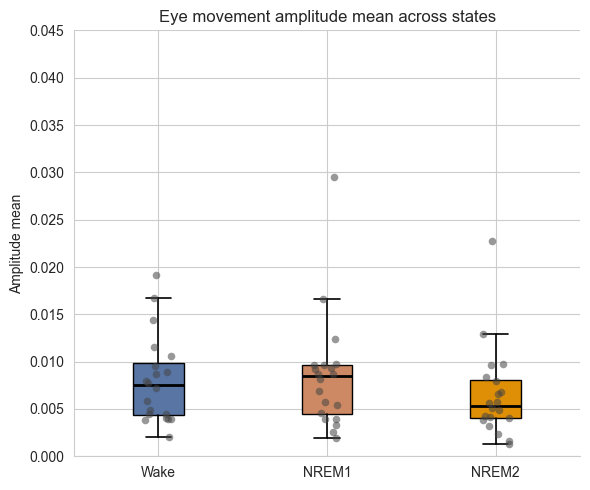

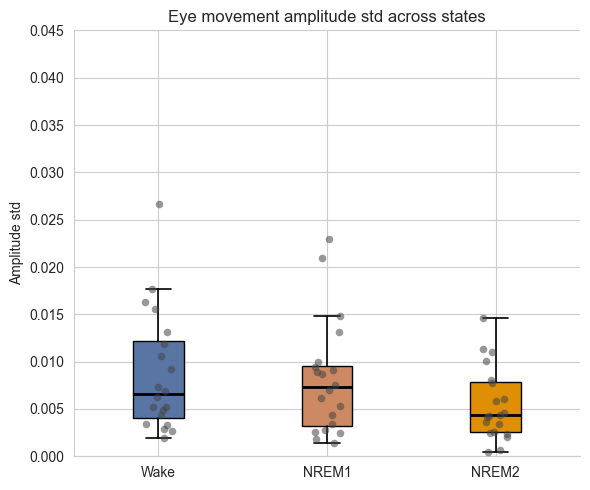

In [11]:



  import matplotlib.pyplot as plt
  import numpy as np

  states_three = {"W": "Wake", "1": "NREM1", "2": "NREM2"}
  colors_three = {"W": "#5875a4ff", "1": "#cc8963ff", "2": "#de8f05ff"}

  for stat_fn, desc in [(np.mean, "mean"), (np.std, "std")]:
      state_values = {}
      for label in states_three:
          state_values[label] = {
              s: stat_fn(np.concatenate([b for b, l in subject_blocks_three_state[s] if l == label]))
              for s in subject_blocks_three_state
              if any(l == label for _, l in subject_blocks_three_state[s])
          }

      fig, ax = plt.subplots(figsize=(6, 5))

      positions = list(range(len(states_three)))
      labels = list(states_three.keys())

      bp = ax.boxplot(
          [np.array([v for v in state_values[l].values() if not np.isnan(v)]) for l in labels],
          positions=positions,
          widths=0.3,
          patch_artist=True,
          showfliers=False,
          medianprops=dict(color='black', linewidth=2),
          whiskerprops=dict(linewidth=1.2),
          capprops=dict(linewidth=1.2),
          zorder=2,
      )

      for patch, label in zip(bp['boxes'], labels):
          patch.set_facecolor(colors_three[label])
          patch.set_alpha(1)

      for j, label in enumerate(labels):
          valid = np.array([v for v in state_values[label].values() if not np.isnan(v)])
          jitter = np.random.uniform(-0.08, 0.08, len(valid))
          ax.scatter(
              np.full(len(valid), j) + jitter,
              valid,
              color="#4444448c", alpha=0.55, s=30, zorder=3,
              edgecolors='white', linewidths=0,
          )

      ax.set_xticks(positions)
      ax.set_xticklabels(states_three.values())
      ax.set_ylabel(f"Amplitude {desc}")
      ax.set_ylim(0, 0.045)
      ax.spines[["top", "right"]].set_visible(False)
      ax.set_title(f"Eye movement amplitude {desc} across states")

      plt.tight_layout()
      plt.show()
      fig.savefig(f"/Users/zach/2025_RA/matthias/final images/eye_voxels/{desc}_amplitude_three_states.svg", dpi=300)



In [67]:

print(f"Mean amplitude: {l1}-{l2} = {results_mean['observed_group']:.4f}, p = {results_mean['p_value']:.4f}")
print(f"Variance:      {l1}-{l2} = {results_var['observed_group']:.4f},  p = {results_var['p_value']:.4f}")
print(f"Median:       {l1}-{l2} = {results_median['observed_group']:.4f},  p = {results_median['p_value']:.4f}")

Mean amplitude: W-1 = -0.0021, p = 0.0003
Variance:      W-1 = -0.0001,  p = 0.0064
Median:       W-1 = -0.0021,  p = 0.0000


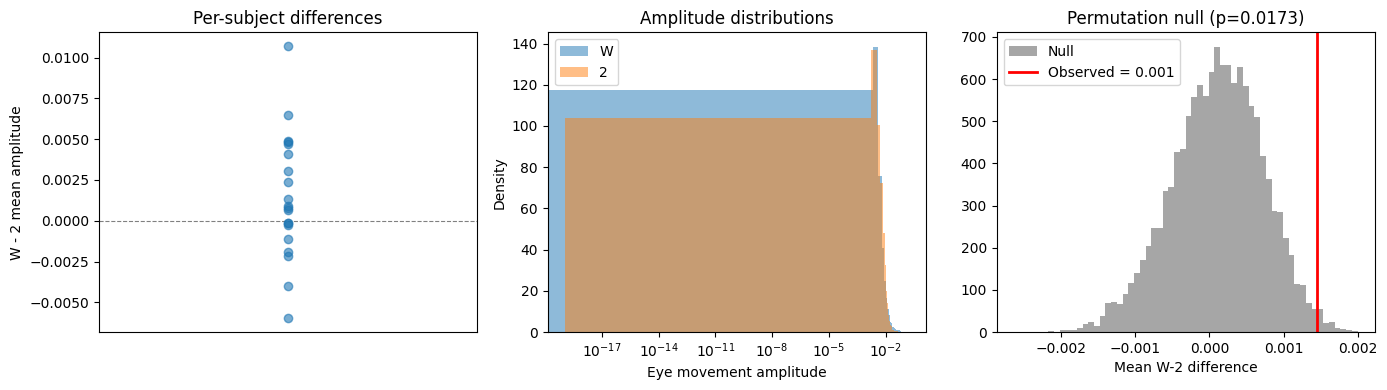

In [64]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

stat = "mean"
result = results_mean


# 1. Per-subject W-S mean differences (paired)
subjects = list(subject_blocks.keys())
per_subject = np.array([compute_statistic(subject_blocks[s], stat) for s in subjects])

axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].plot(np.zeros(len(per_subject)), per_subject, 'o', alpha=0.6)
axes[0].set_xticks([])
axes[0].set_ylabel(f"{l1} - {l2} {stat} amplitude")
axes[0].set_title("Per-subject differences")

# 2. Distribution of pooled wake vs sleep values across all subjects
all_wake = np.concatenate([
    np.concatenate([b for b, l in subject_blocks[s] if l == l1]) for s in subjects
])
all_sleep = np.concatenate([
    np.concatenate([b for b, l in subject_blocks[s] if l == l2]) for s in subjects
])

axes[1].hist(all_wake, bins=80, alpha=0.5, label=l1, density=True)
axes[1].hist(all_sleep, bins=80, alpha=0.5, label=l2, density=True)
axes[1].set_xlabel("Eye movement amplitude")
axes[1].set_ylabel("Density")
axes[1].set_title("Amplitude distributions")
# axes[1].set_xscale('log')
axes[1].legend()

# 3. Null distribution with observed statistic
axes[2].hist(result["null_distribution"], bins=60, density=True, 
             color='gray', alpha=0.7, label="Null")
axes[2].axvline(result["observed_group"], color='red', 
                linewidth=2, label=f"Observed = {result['observed_group']:.3f}")
axes[2].set_xlabel(f"{stat.capitalize()} {l1}-{l2} difference")
axes[2].set_title(f"Permutation null (p={result['p_value']:.4f})")
axes[2].legend()

plt.tight_layout()
plt.show()

In [70]:
subjects = list(subject_blocks.keys())
all_wake = np.concatenate([np.concatenate([b for b, l in subject_blocks[s] if l == l1]) for s in subjects])
all_sleep = np.concatenate([np.concatenate([b for b, l in subject_blocks[s] if l == l2]) for s in subjects])

print(f"{l1} mean: {np.mean(all_wake):.4f}, {l2} mean: {np.mean(all_sleep):.4f}")
print(f"{l1} median: {np.median(all_wake):.4f}, {l2} median: {np.median(all_sleep):.4f}")
print(f"{l1} var: {np.var(all_wake):.6f}, {l2} var: {np.var(all_sleep):.6f}")

W mean: 0.0091, 1 mean: 0.0084
W median: 0.0046, 1 median: 0.0051
W var: 0.000184, 1 var: 0.000141


In [122]:
mrio.load
for label, state_name in states.items():
    block_lengths = [
        len(b) for s in subject_blocks_three_state
        for b, l in subject_blocks_three_state[s]
        if l == label and len(b) >= min_block_len
    ]
    print(f"{state_name}: n_blocks={len(block_lengths)}, "
          f"mean_length={np.mean(block_lengths):.1f}, "
          f"median_length={np.median(block_lengths):.1f}")
    

Wake: n_blocks=164, mean_length=119.1, median_length=55.0
1: n_blocks=239, mean_length=64.7, median_length=41.0
2: n_blocks=125, mean_length=89.5, median_length=56.0
